# Time Series Analysis — ISP Network Traffic Forecasting

**Dataset:** `isp_traffic_ts.csv` — 5-min intervals, 6 months of ISP backbone throughput

| Section | Topic |
|---------|-------|
| 1 | Data Loading & Preprocessing |
| 2 | Exploratory Data Analysis |
| 3 | Stationarity Testing (ADF, KPSS, Phillips-Perron) |
| 4 | ACF / PACF Analysis |
| 5 | **SARIMAX** — Seasonal ARIMA with Exogenous Variables (Linear) |
| 6 | Residual Diagnostics & Cross-Validation |
| 7 | Non-Linearity Tests (ARCH-LM, Tsay, Teräsvirta) |
| 8 | **SETAR** — Self-Exciting Threshold Autoregression (Non-Linear) |
| 9 | **GRU** — Gated Recurrent Unit (Deep Learning, PyTorch) |
| 10 | Model Comparison & Conclusion |

## 0. Library Imports

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch.unitroot import PhillipsPerron
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 11

print("All libraries loaded.")

All libraries loaded.


## 1. Data Loading & Preprocessing

In [2]:
df_raw = pd.read_csv('isp_traffic_ts.csv', parse_dates=['timestamp'], index_col='timestamp')
print(f"Raw: {df_raw.shape}  |  {df_raw.index[0]} → {df_raw.index[-1]}")

# Resample to hourly — smoother, keeps patterns
df = df_raw.resample('1h').mean().dropna()
print(f"Hourly: {df.shape}")

TARGET = 'flowBytesPerSecond'
ts = df[TARGET]
print(f"\nTarget: {TARGET}")
print(ts.describe().round(0))

Raw: (52417, 7)  |  2024-01-01 00:00:00 → 2024-07-01 00:00:00
Hourly: (4369, 7)

Target: flowBytesPerSecond
count        4369.0
mean     60181593.0
std       5243530.0
min      44718406.0
25%      56564364.0
50%      60065476.0
75%      63585692.0
max      80637598.0
Name: flowBytesPerSecond, dtype: float64


## 2. Exploratory Data Analysis

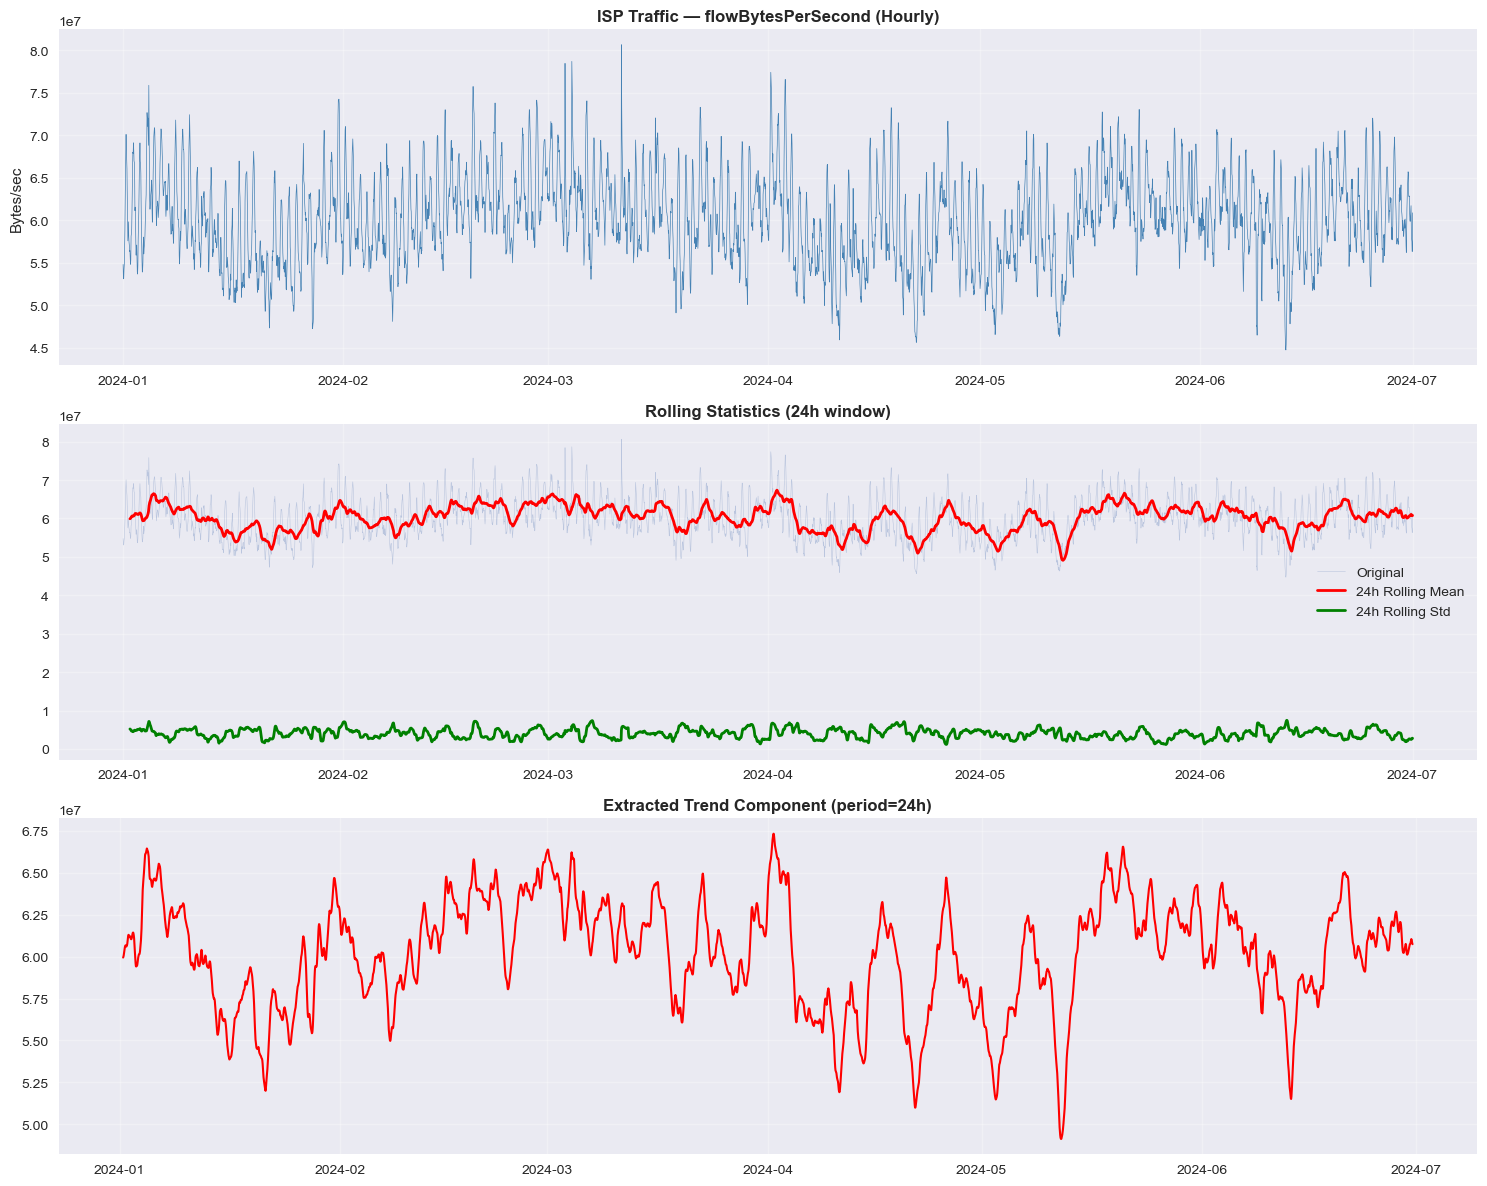

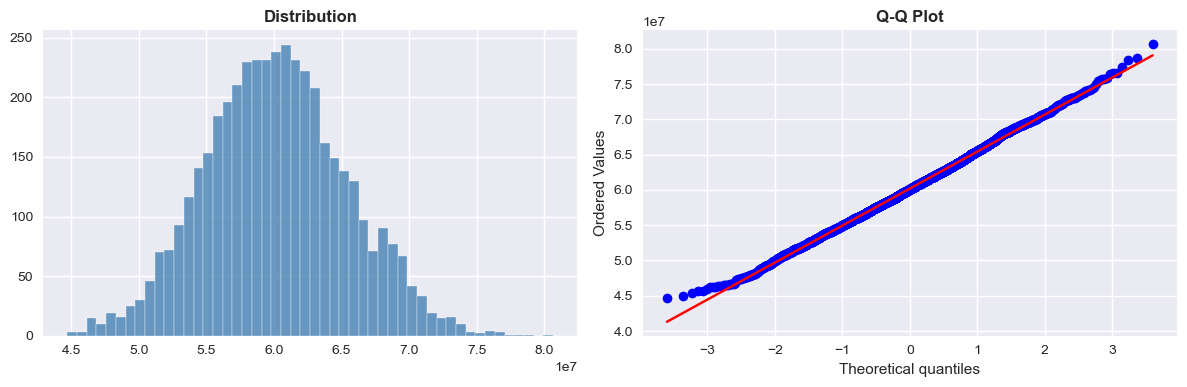

Skewness : 0.116
Kurtosis : -0.059


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(ts, lw=0.5, color='steelblue')
axes[0].set_title('ISP Traffic — flowBytesPerSecond (Hourly)', fontweight='bold')
axes[0].set_ylabel('Bytes/sec')
axes[0].grid(True, alpha=0.3)

# Rolling stats
rm = ts.rolling(24).mean()
rs = ts.rolling(24).std()
axes[1].plot(ts, alpha=0.3, lw=0.4, label='Original')
axes[1].plot(rm, label='24h Rolling Mean', color='red', lw=2)
axes[1].plot(rs, label='24h Rolling Std', color='green', lw=2)
axes[1].set_title('Rolling Statistics (24h window)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Seasonal decomposition
decomp = seasonal_decompose(ts, model='additive', period=24)
axes[2].plot(decomp.trend, label='Trend', color='red', lw=1.5)
axes[2].set_title('Extracted Trend Component (period=24h)', fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ts, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution', fontweight='bold')
stats.probplot(ts, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness : {ts.skew():.3f}")
print(f"Kurtosis : {ts.kurtosis():.3f}")

## 3. Stationarity Testing

| Test | H₀ | Stationary if |
|------|----|---------------|
| **ADF** | Unit root | p ≤ 0.05 |
| **KPSS** | Stationary | p > 0.05 |
| **PP** | Unit root | p ≤ 0.05 |

In [4]:
def stationarity_battery(series, name=''):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    pp = PhillipsPerron(s)

    adf_ok  = adf_p <= 0.05
    kpss_ok = kpss_p >= 0.05
    pp_ok   = pp.pvalue <= 0.05

    print(f"{'─'*70}")
    print(f"STATIONARITY  |  {name}  |  n = {len(s)}")
    print(f"{'─'*70}")
    print(f"  ADF  : stat={adf_stat:.4f}  p={adf_p:.4f}  → {'STATIONARY' if adf_ok else 'non-stationary'}")
    print(f"  KPSS : stat={kpss_stat:.4f}  p={kpss_p:.4f}  → {'STATIONARY' if kpss_ok else 'non-stationary'}")
    print(f"  PP   : stat={pp.stat:.4f}  p={pp.pvalue:.4f}  → {'STATIONARY' if pp_ok else 'non-stationary'}")
    result = 'STATIONARY' if all([adf_ok, kpss_ok, pp_ok]) else 'NON-STATIONARY'
    print(f"  Conclusion: {result}")
    print(f"{'─'*70}")
    return all([adf_ok, kpss_ok, pp_ok])

raw_stationary = stationarity_battery(ts, 'Raw series')

# Find d
d = 0
current = ts.copy()
for dd in range(3):
    if stationarity_battery(current, f'd={dd}'):
        d = dd
        break
    current = current.diff().dropna()
    d = dd + 1

print(f"\n=> Differencing order d = {d}")

──────────────────────────────────────────────────────────────────────
STATIONARITY  |  Raw series  |  n = 4369
──────────────────────────────────────────────────────────────────────
  ADF  : stat=-5.5020  p=0.0000  → STATIONARY
  KPSS : stat=0.3206  p=0.1000  → STATIONARY
  PP   : stat=-10.4835  p=0.0000  → STATIONARY
  Conclusion: STATIONARY
──────────────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────────────
STATIONARITY  |  d=0  |  n = 4369
──────────────────────────────────────────────────────────────────────
  ADF  : stat=-5.5020  p=0.0000  → STATIONARY
  KPSS : stat=0.3206  p=0.1000  → STATIONARY
  PP   : stat=-10.4835  p=0.0000  → STATIONARY
  Conclusion: STATIONARY
──────────────────────────────────────────────────────────────────────

=> Differencing order d = 0


/var/folders/12/r43t89297573tsmzccbf4rnr0000gn/T/ipykernel_84339/4026236580.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/var/folders/12/r43t89297573tsmzccbf4rnr0000gn/T/ipykernel_84339/4026236580.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


/var/folders/12/r43t89297573tsmzccbf4rnr0000gn/T/ipykernel_82384/4026236580.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/var/folders/12/r43t89297573tsmzccbf4rnr0000gn/T/ipykernel_82384/4026236580.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


## 4. ACF / PACF Analysis

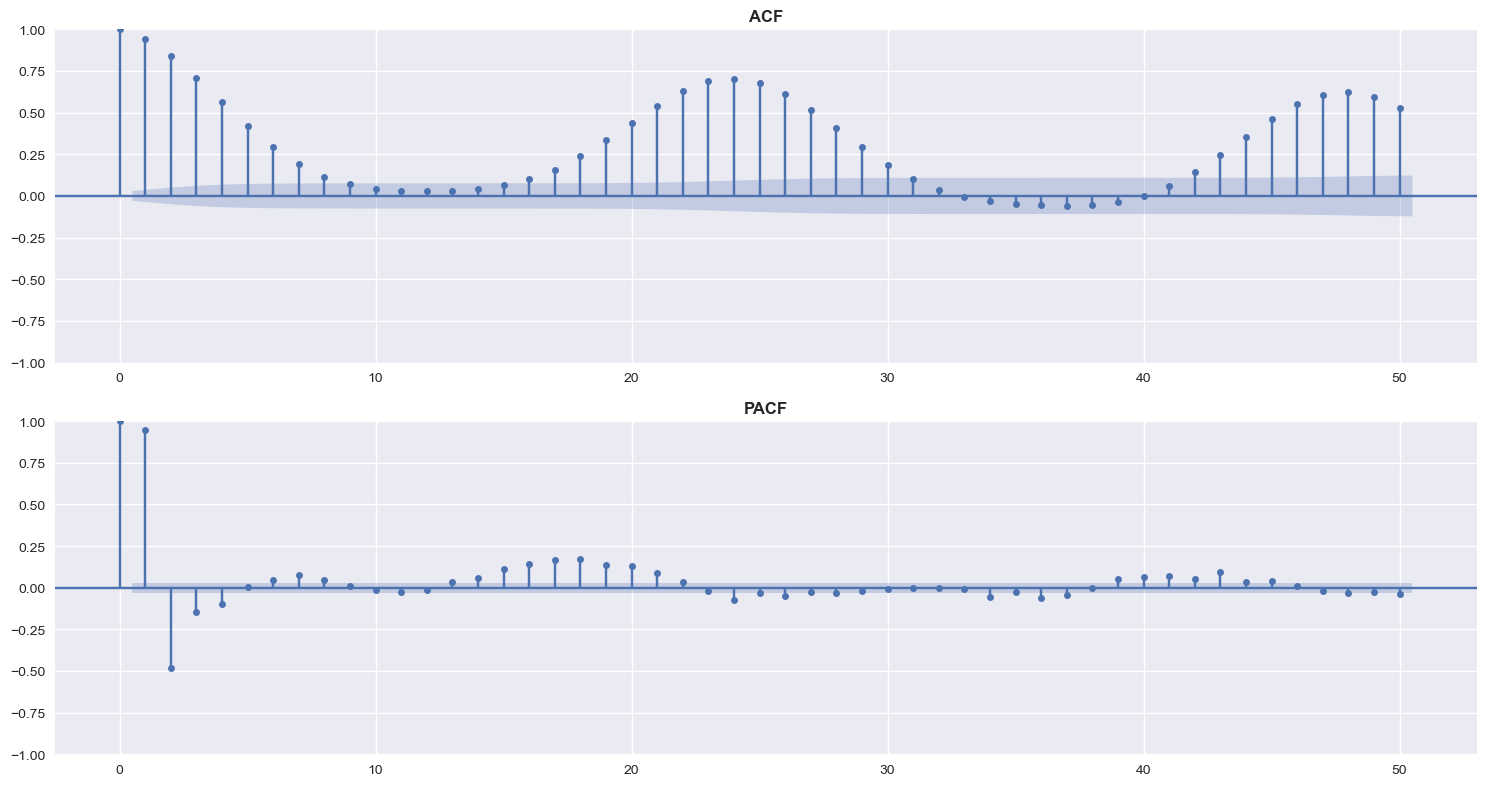

In [5]:
stationary_series = ts.diff(d).dropna() if d > 0 else ts

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(stationary_series, lags=50, ax=axes[0])
axes[0].set_title('ACF', fontweight='bold')
plot_pacf(stationary_series, lags=50, method='ywm', ax=axes[1])
axes[1].set_title('PACF', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. SARIMAX — Seasonal ARIMA with Exogenous Variables (Linear)

We use SARIMAX with seasonal order (P, D, Q, S=24) to capture the daily cycle.
The rolling 1-step-ahead protocol ensures fair out-of-sample evaluation.

In [6]:
# -- Train/test split (80/20) ---------------------------------------------------
TRAIN_FRAC = 0.8
train_size = int(len(ts) * TRAIN_FRAC)
train_ts = ts.iloc[:train_size]
test_ts  = ts.iloc[train_size:]

# Exogenous: hour-of-day encoded as sin/cos (captures daily cycle independently)
def make_exog(idx):
    h = idx.hour + idx.minute / 60.0
    return pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * h / 24),
        'hour_cos': np.cos(2 * np.pi * h / 24),
    }, index=idx)

exog_train = make_exog(train_ts.index)
exog_test  = make_exog(test_ts.index)

print(f"Train: {len(train_ts)}  |  Test: {len(test_ts)}")
print(f"Split at: {train_ts.index[-1]}")

Train: 3495  |  Test: 874
Split at: 2024-05-25 14:00:00


In [7]:
# -- Fit SARIMAX ---------------------------------------------------------------
# order (p,d,q) and seasonal_order (P,D,Q,s)
order = (2, d, 1)
seasonal_order = (1, 0, 1, 24)  # daily season

print(f"Fitting SARIMAX{order}x{seasonal_order}...")
model = SARIMAX(train_ts, exog=exog_train,
                order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(method_kwargs={'maxiter': 300})
print(model_fit.summary())

Fitting SARIMAX(2, 0, 1)x(1, 0, 1, 24)...
                                     SARIMAX Results                                      
Dep. Variable:                 flowBytesPerSecond   No. Observations:                 3495
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -54142.183
Date:                            Mon, 09 Mar 2026   AIC                         108300.367
Time:                                    23:31:45   BIC                         108349.580
Sample:                                01-01-2024   HQIC                        108317.938
                                     - 05-25-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hour_sin    2.012e+06    5.6e-10   3.59e+15      0.000    2.01e+06    2.

                                     SARIMAX Results                                      
Dep. Variable:                 flowBytesPerSecond   No. Observations:                 3495
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -54142.183
Date:                            Mon, 09 Mar 2026   AIC                         108300.367
Time:                                    23:23:04   BIC                         108349.580
Sample:                                01-01-2024   HQIC                        108317.938
                                     - 05-25-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hour_sin    2.012e+06    5.6e-10   3.59e+15      0.000    2.01e+06    2.01e+06
hour_cos    -4.19e+06   5.33e-10  -


Rolling 1-step-ahead over 874 test points...
  200/874
  400/874
  600/874
  800/874

SARIMAX Results:
  RMSE : 1,463,556
  MAE  : 1,091,097
  R²   : 0.8969
  AIC  : 108300  |  BIC  : 108350


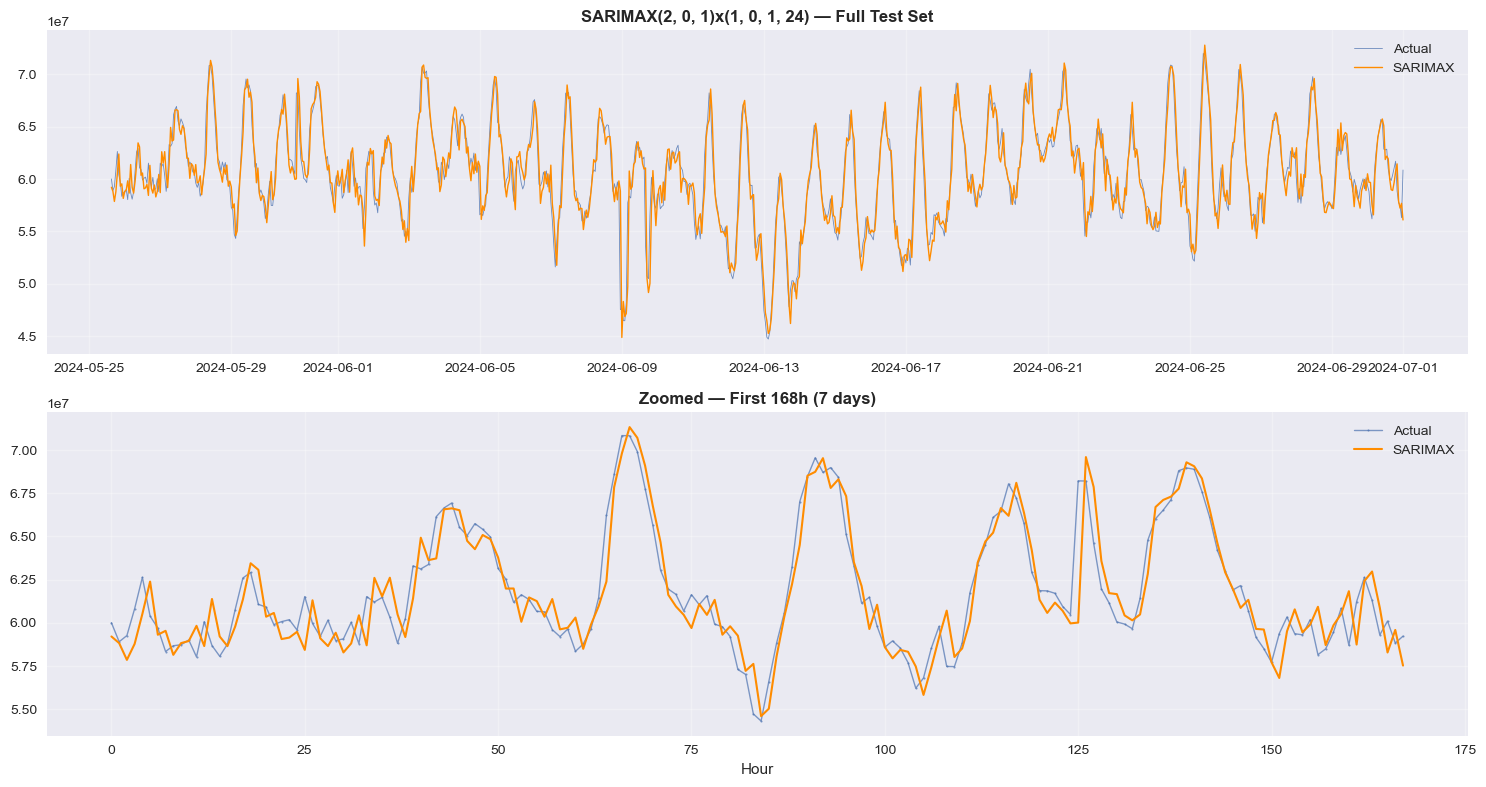

  400/874


  600/874


  800/874



SARIMAX Results:
  RMSE : 1,463,556
  MAE  : 1,091,097
  R²   : 0.8969
  AIC  : 108300  |  BIC  : 108350


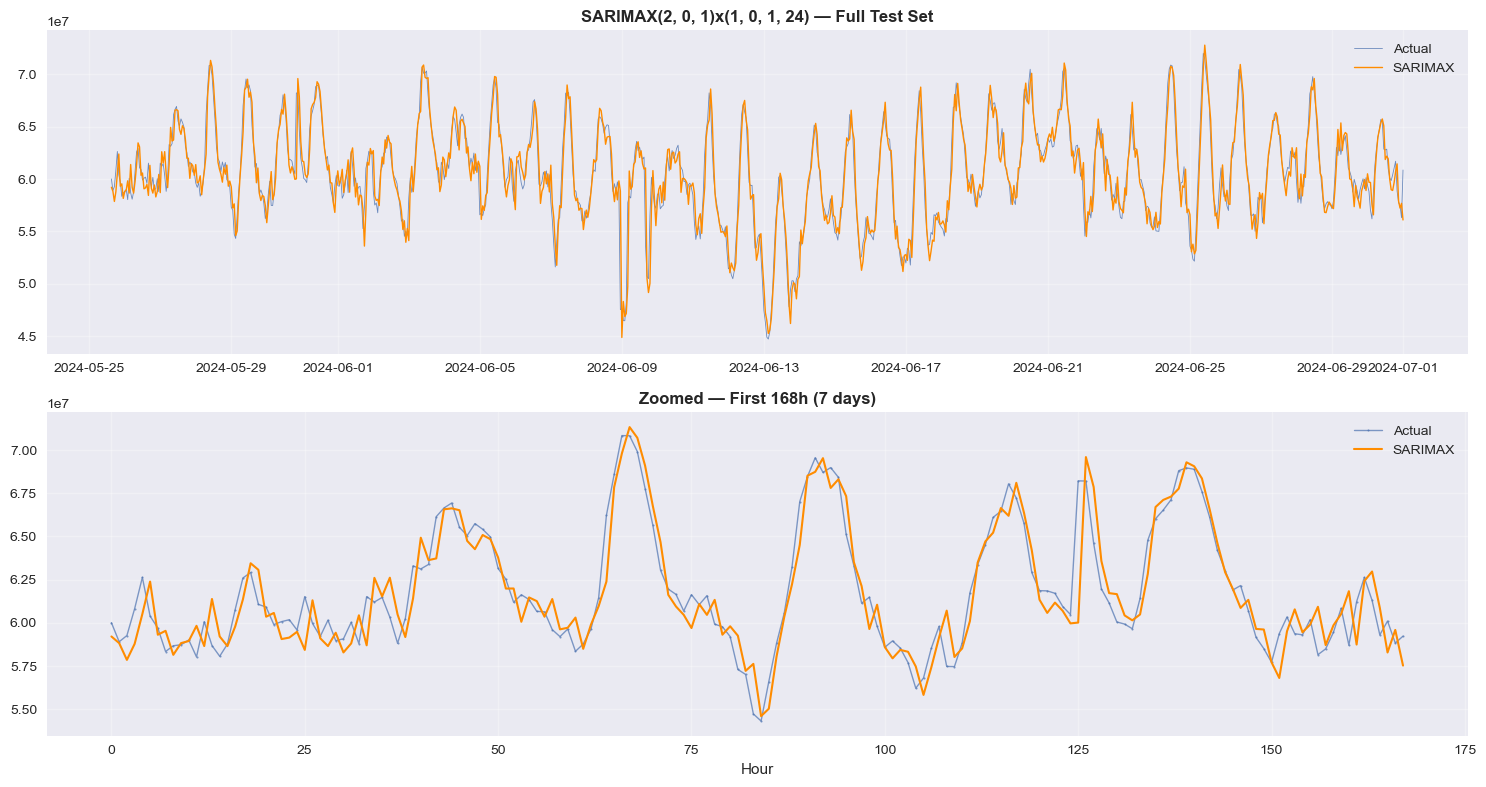

In [8]:
# -- Rolling 1-step-ahead forecast ----------------------------------------------
print(f"\nRolling 1-step-ahead over {len(test_ts)} test points...")
res = model_fit
forecasts = []

for i in range(len(test_ts)):
    fc = res.forecast(steps=1, exog=exog_test.values[i:i+1])
    forecasts.append(float(np.atleast_1d(fc)[0]))
    # Append actual observation (no refit — fast)
    res = res.append(test_ts.iloc[[i]], exog=exog_test.iloc[[i]], refit=False)
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(test_ts)}")

sarimax_pred = pd.Series(forecasts, index=test_ts.index)
sarimax_rmse = np.sqrt(mean_squared_error(test_ts, sarimax_pred))
sarimax_mae  = mean_absolute_error(test_ts, sarimax_pred)
sarimax_r2   = r2_score(test_ts, sarimax_pred)

print(f"\nSARIMAX Results:")
print(f"  RMSE : {sarimax_rmse:,.0f}")
print(f"  MAE  : {sarimax_mae:,.0f}")
print(f"  R²   : {sarimax_r2:.4f}")
print(f"  AIC  : {model_fit.aic:.0f}  |  BIC  : {model_fit.bic:.0f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
# Full view
axes[0].plot(test_ts.index, test_ts.values, lw=0.6, label='Actual', alpha=0.8)
axes[0].plot(test_ts.index, sarimax_pred.values, lw=1, label='SARIMAX', color='darkorange')
axes[0].set_title(f'SARIMAX{order}x{seasonal_order} — Full Test Set', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed (1 week)
n_zoom = min(168, len(test_ts))
axes[1].plot(test_ts.values[:n_zoom], lw=1, label='Actual', marker='.', ms=3, alpha=0.7)
axes[1].plot(sarimax_pred.values[:n_zoom], lw=1.5, label='SARIMAX', color='darkorange')
axes[1].set_title(f'Zoomed — First {n_zoom}h ({n_zoom//24} days)', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 Residual Diagnostics

| Test | What it checks | Good if |
|------|----------------|---------|
| **Ljung-Box** | Serial correlation | p > 0.05 |
| **Jarque-Bera** | Normality | p > 0.05 |
| **ARCH-LM** | Constant variance | p > 0.05 |

RESIDUAL DIAGNOSTICS
──────────────────────────────────────────────────────────────────────
Ljung-Box: FAIL ✗
       lb_stat     lb_pvalue
10  132.387363  1.521039e-23
20  210.233830  1.052091e-33
30  366.957511  1.259630e-59

Jarque-Bera: stat=15663176.12  p=0.0000  → Non-normal
ARCH-LM:     stat=73.65  p=0.0000  → Heteroscedastic


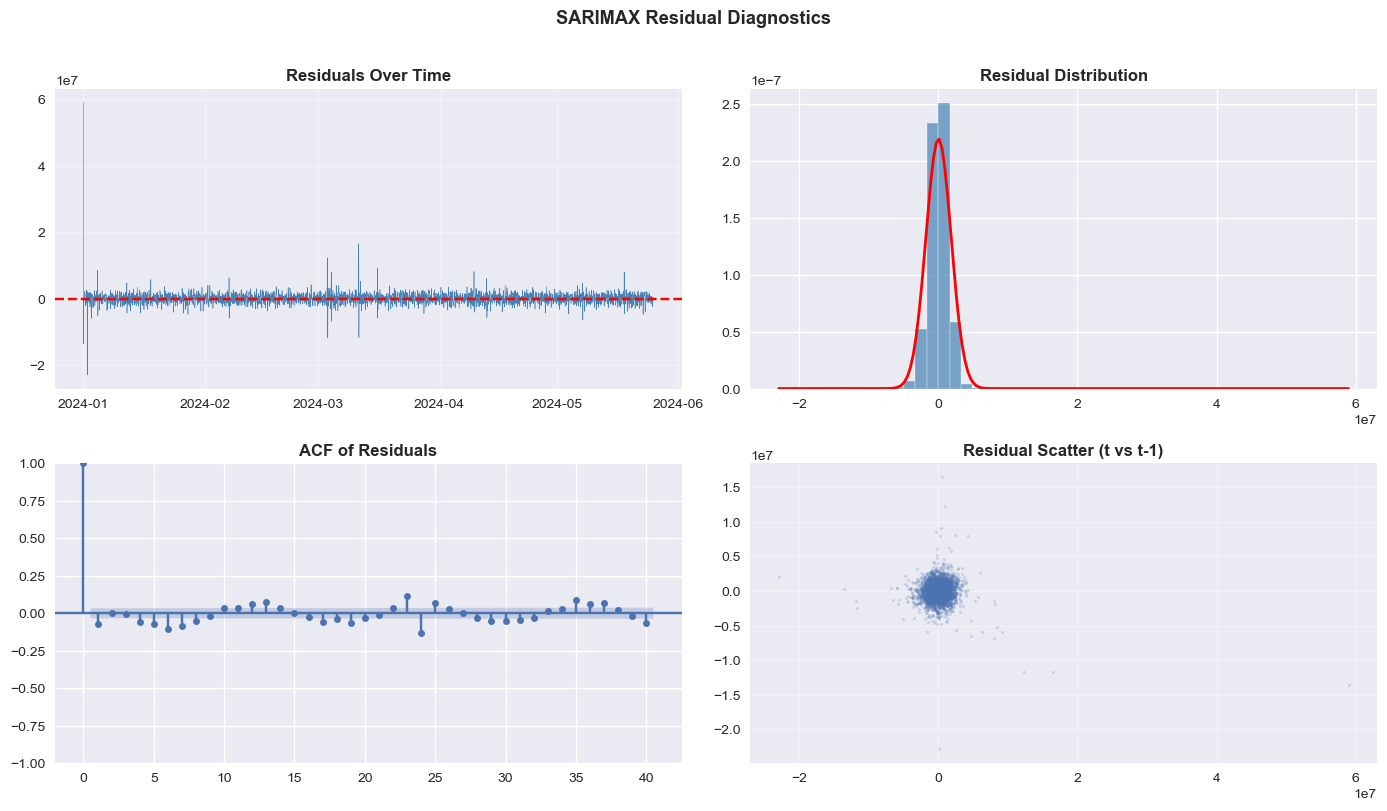

In [9]:
residuals = model_fit.resid
SEP = '─' * 70
print('RESIDUAL DIAGNOSTICS')
print(SEP)

# Ljung-Box
lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
lb_pass = (lb['lb_pvalue'] > 0.05).all()
print(f"Ljung-Box: {'PASS ✓' if lb_pass else 'FAIL ✗'}")
print(lb.to_string())

# Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"\nJarque-Bera: stat={jb_stat:.2f}  p={jb_p:.4f}  → {'Normal' if jb_p > 0.05 else 'Non-normal'}")

# ARCH-LM
lm_stat, lm_p, *_ = het_arch(residuals, nlags=10)
print(f"ARCH-LM:     stat={lm_stat:.2f}  p={lm_p:.4f}  → {'Homoscedastic' if lm_p > 0.05 else 'Heteroscedastic'}")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(residuals, lw=0.4, color='steelblue')
axes[0,0].axhline(0, color='red', ls='--')
axes[0,0].set_title('Residuals Over Time', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x_g = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,1].plot(x_g, norm.pdf(x_g, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0,1].set_title('Residual Distribution', fontweight='bold')

plot_acf(residuals, ax=axes[1,0], lags=40)
axes[1,0].set_title('ACF of Residuals', fontweight='bold')

axes[1,1].scatter(residuals.iloc[:-1], residuals.iloc[1:], alpha=0.2, s=3)
axes[1,1].set_title('Residual Scatter (t vs t-1)', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
plt.suptitle('SARIMAX Residual Diagnostics', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Cross-Validation (Expanding Window)

In [ ]:
print('SARIMAX — 5-Fold Expanding-Window CV')
cv_rows = []
for fold, (tr_i, te_i) in enumerate(TimeSeriesSplit(n_splits=5).split(ts), 1):
    tr, te = ts.iloc[tr_i], ts.iloc[te_i]
    ex_tr = make_exog(tr.index)
    ex_te = make_exog(te.index)
    try:
        fit = SARIMAX(tr, exog=ex_tr, order=order, seasonal_order=seasonal_order,
                      enforce_stationarity=False, enforce_invertibility=False
                      ).fit(method_kwargs={'maxiter': 200})
        fc = fit.forecast(steps=len(te), exog=ex_te)
        rmse = np.sqrt(mean_squared_error(te, fc))
        mae  = mean_absolute_error(te, fc)
        cv_rows.append({'fold': fold, 'rmse': rmse, 'mae': mae})
        print(f"  Fold {fold}: RMSE={rmse:,.0f}  MAE={mae:,.0f}")
    except Exception as e:
        print(f"  Fold {fold}: FAILED — {e}")

cv = pd.DataFrame(cv_rows)
print(f"\n  Mean RMSE: {cv['rmse'].mean():,.0f} ± {cv['rmse'].std():,.0f}")

SARIMAX — 5-Fold Expanding-Window CV
  Fold 1: RMSE=7,314,750  MAE=6,322,152
  Fold 2: RMSE=12,717,123  MAE=10,947,927
  Fold 3: RMSE=12,169,812  MAE=9,782,943
  Fold 4: RMSE=19,293,618  MAE=16,602,649


  Fold 1: RMSE=7,314,750  MAE=6,322,152


  Fold 2: RMSE=12,717,123  MAE=10,947,927


  Fold 3: RMSE=12,169,812  MAE=9,782,943


  Fold 4: RMSE=19,293,618  MAE=16,602,649


  Fold 5: RMSE=16,211,136  MAE=13,800,186

  Mean RMSE: 13,541,288 ± 4,515,179


## 7. Non-Linearity Assessment

| Test | H₀ | Rejects → |
|------|-----|-----------|
| **ARCH-LM** | No ARCH effects | GARCH needed |
| **Tsay F-test** | Linear AR | Threshold / SETAR |
| **Teräsvirta NN** | Linearity | Smooth transition / STAR |

In [ ]:
SEP = '═' * 70
print(SEP)
print('NON-LINEARITY ASSESSMENT')
print(SEP)

# 1. ARCH-LM (already computed)
print(f"\n1. ARCH-LM:  stat={lm_stat:.4f}  p={lm_p:.4f}")
print(f"   → {'No ARCH effects' if lm_p >= 0.05 else 'ARCH effects detected — GARCH warranted'}")

# 2. Tsay F-test
def tsay_test(resid, p=2, delay=1):
    resid = resid.reset_index(drop=True)
    T = len(resid)
    Y = resid.iloc[p:T].values
    X = np.column_stack([resid.iloc[p-i:T-i].values for i in range(1, p+1)])
    tv = resid.iloc[p-delay:T-delay].values
    idx = np.argsort(tv)
    Y_s, X_s = Y[idx], X[idx]
    n, m0 = len(Y_s), p + 5
    e_arr = []
    for t_i in range(m0, n):
        b = np.linalg.lstsq(X_s[:t_i], Y_s[:t_i], rcond=None)[0]
        e_arr.append(Y_s[t_i] - X_s[t_i] @ b)
    e_arr = np.array(e_arr)
    tv_s = tv[idx][m0:]
    Z = np.column_stack([np.ones(len(tv_s)), tv_s])
    b2 = np.linalg.lstsq(Z, e_arr, rcond=None)[0]
    SSR_u = np.sum((e_arr - Z @ b2)**2)
    SSR_r = np.sum(e_arr**2)
    F = ((SSR_r - SSR_u) / 2) / (SSR_u / (len(e_arr) - 2))
    return F, float(1 - stats.f.cdf(F, 2, len(e_arr) - 2))

f_tsay, p_tsay = tsay_test(residuals)
print(f"\n2. Tsay F:   stat={f_tsay:.4f}  p={p_tsay:.4f}")
print(f"   → {'Linear OK' if p_tsay >= 0.05 else 'Threshold nonlinearity — SETAR warranted'}")

# 3. Teräsvirta NN
def terasvirta_test(resid, p=2):
    r = resid.reset_index(drop=True).values
    T = len(r)
    Y = r[p:]
    X_lin = np.hstack([np.ones((T-p,1)), np.column_stack([r[p-i:T-i] for i in range(1,p+1)])])
    X_nl  = np.column_stack([r[p-i:T-i]**3 for i in range(1,p+1)])
    X_f   = np.hstack([X_lin, X_nl])
    b_r = np.linalg.lstsq(X_lin, Y, rcond=None)[0]
    SSR_r = np.sum((Y - X_lin @ b_r)**2)
    b_u = np.linalg.lstsq(X_f, Y, rcond=None)[0]
    SSR_u = np.sum((Y - X_f @ b_u)**2)
    n, k_r, k_u = len(Y), X_lin.shape[1], X_f.shape[1]
    F = ((SSR_r - SSR_u) / (k_u - k_r)) / (SSR_u / (n - k_u))
    return F, float(1 - stats.f.cdf(F, k_u - k_r, n - k_u))

f_ter, p_ter = terasvirta_test(residuals)
print(f"\n3. Teräsvirta: stat={f_ter:.4f}  p={p_ter:.4f}")
print(f"   → {'Linear OK' if p_ter >= 0.05 else 'Smooth-transition nonlinearity detected'}")

print(f"\n{SEP}")
print("SUMMARY:")
print(f"  ARCH-LM   : {'NOT required' if lm_p >= 0.05 else 'WARRANTED'}")
print(f"  Tsay (TAR) : {'NOT required' if p_tsay >= 0.05 else 'WARRANTED'}")
print(f"  Teräsvirta : {'NOT required' if p_ter >= 0.05 else 'WARRANTED'}")
print(f"\nWe fit SETAR as a non-linear benchmark regardless.")
print(SEP)

## 8. SETAR — Self-Exciting Threshold Autoregression (Non-Linear)

SETAR splits data into regimes based on a threshold value of the lagged series
and fits separate AR models per regime. Same rolling 1-step-ahead protocol.

In [ ]:
print('SETAR(2; 4, 4) — fitting on training data...')

def fit_setar(series, p=4):
    y = series.values
    n_s = len(y)
    Y = y[p:]
    X = np.column_stack([y[p-i:n_s-i] for i in range(1, p+1)])
    tv = y[p-1:n_s-1]
    best_rss, best_thresh, best_coefs = np.inf, None, None
    for thresh in np.percentile(tv, np.arange(15, 86)):
        lo, hi = tv <= thresh, tv > thresh
        if lo.sum() < p + 2 or hi.sum() < p + 2:
            continue
        X_lo = np.hstack([np.ones((lo.sum(),1)), X[lo]])
        X_hi = np.hstack([np.ones((hi.sum(),1)), X[hi]])
        b_lo = np.linalg.lstsq(X_lo, Y[lo], rcond=None)[0]
        b_hi = np.linalg.lstsq(X_hi, Y[hi], rcond=None)[0]
        rss = np.sum((Y[lo] - X_lo @ b_lo)**2) + np.sum((Y[hi] - X_hi @ b_hi)**2)
        if rss < best_rss:
            best_rss, best_thresh, best_coefs = rss, thresh, (b_lo, b_hi)
    return best_thresh, best_coefs

P_SETAR = 4
threshold, (c_lo, c_hi) = fit_setar(train_ts, P_SETAR)
print(f"Threshold: {threshold:,.0f}")
print(f"Regime 1 coefs: {np.round(c_lo, 4)}")
print(f"Regime 2 coefs: {np.round(c_hi, 4)}")

# Rolling 1-step-ahead
history = list(train_ts.values)
setar_preds = []
for actual in test_ts.values:
    lags = [history[-j] for j in range(1, P_SETAR+1)]
    x = np.concatenate([[1.0], lags])
    pred = x @ (c_lo if history[-1] <= threshold else c_hi)
    setar_preds.append(pred)
    history.append(actual)

setar_preds = np.array(setar_preds)
setar_rmse = np.sqrt(mean_squared_error(test_ts, setar_preds))
setar_mae  = mean_absolute_error(test_ts, setar_preds)
setar_r2   = r2_score(test_ts, setar_preds)

print(f"\nSETAR Results:")
print(f"  RMSE : {setar_rmse:,.0f}")
print(f"  MAE  : {setar_mae:,.0f}")
print(f"  R²   : {setar_r2:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(test_ts.values, lw=0.6, label='Actual', alpha=0.8)
axes[0].plot(setar_preds, lw=1, label='SETAR', color='seagreen')
axes[0].set_title('SETAR(2; 4, 4) — Full Test Set', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_zoom = min(168, len(test_ts))
axes[1].plot(test_ts.values[:n_zoom], lw=1, label='Actual', marker='.', ms=3, alpha=0.7)
axes[1].plot(setar_preds[:n_zoom], lw=1.5, label='SETAR', color='seagreen')
axes[1].set_title(f'Zoomed — First {n_zoom//24} days', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. GRU — Gated Recurrent Unit (Deep Learning, PyTorch)

**Architecture:** 2-layer GRU with 128 units, multivariate input (all 7 features),
lookback window of 48 hours. Early stopping on held-out validation set.
Same rolling 1-step-ahead forecast protocol.

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# -- Hyperparameters -----------------------------------------------------------
LOOKBACK  = 48      # hours
N_FEAT    = 7       # all numeric columns
HIDDEN    = 128
N_LAYERS  = 2
DROPOUT   = 0.15
LR        = 5e-4
BATCH     = 64
EPOCHS    = 80
PATIENCE  = 12

# -- Data prep (NO LEAKAGE: scaler fit on train only) -------------------------
all_cols = ['flowBytesPerSecond', 'flowPktsPerSecond', 'flowsPerSecond',
            'mean_flowiat_ms', 'pkt_loss_rate', 'tcp_udp_ratio', 'bandwidth_utilization']
train_raw = df[all_cols].iloc[:train_size].values
test_raw  = df[all_cols].iloc[train_size:].values

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# Target scaler (for inverse transform)
target_scaler = MinMaxScaler()
target_scaler.fit(train_raw[:, 0:1])

def make_seq(data, lb):
    X = np.array([data[i-lb:i] for i in range(lb, len(data))])
    y = data[lb:, 0]  # target = first column
    return X, y

X_tr, y_tr = make_seq(train_scaled, LOOKBACK)
# Train/val split
val_n = int(len(X_tr) * 0.1)
X_train_t = torch.FloatTensor(X_tr[:-val_n]).to(device)
y_train_t = torch.FloatTensor(y_tr[:-val_n]).to(device)
X_val_t   = torch.FloatTensor(X_tr[-val_n:]).to(device)
y_val_t   = torch.FloatTensor(y_tr[-val_n:]).to(device)

train_dl = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH, shuffle=True)
print(f"Train: {X_train_t.shape}  Val: {X_val_t.shape}  Test: {len(test_scaled)}")

# -- Model --------------------------------------------------------------------
class GRUForecaster(nn.Module):
    def __init__(self, n_feat, hidden, n_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(n_feat, hidden, n_layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1))
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

model = GRUForecaster(N_FEAT, HIDDEN, N_LAYERS, DROPOUT).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
crit  = nn.MSELoss()
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# -- Training ------------------------------------------------------------------
best_vl, patience_cnt, best_st = float('inf'), 0, None
tl_hist, vl_hist = [], []

for ep in range(EPOCHS):
    model.train()
    ep_loss = 0
    for xb, yb in train_dl:
        pred = model(xb)
        loss = crit(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item() * len(xb)
    tl = ep_loss / len(X_train_t)
    tl_hist.append(tl)

    model.eval()
    with torch.no_grad():
        vl = crit(model(X_val_t), y_val_t).item()
    vl_hist.append(vl)
    sched.step(vl)

    if (ep+1) % 10 == 0 or ep == 0:
        print(f"  Epoch {ep+1:3d}  train={tl:.6f}  val={vl:.6f}")
    if vl < best_vl:
        best_vl, patience_cnt = vl, 0
        best_st = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"  Early stop @ epoch {ep+1}")
            break

model.load_state_dict(best_st)
print(f"Best val loss: {best_vl:.6f}")

GRUForecaster(
  (gru): GRU(7, 128, num_layers=2, batch_first=True, dropout=0.15)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 160,001


  Epoch   1  train=0.043124  val=0.016835


  Epoch  10  train=0.004333  val=0.001955


  Epoch  20  train=0.003666  val=0.001751


  Epoch  30  train=0.003566  val=0.001822


  Epoch  40  train=0.003206  val=0.001602


  Epoch  50  train=0.003029  val=0.001599


  Early stop @ epoch 53
Best val loss: 0.001545


In [ ]:
# -- Rolling 1-step-ahead forecast (multivariate) ------------------------------
model.eval()
all_scaled = np.vstack([train_scaled, test_scaled])

preds_scaled = []
with torch.no_grad():
    for i in range(len(test_scaled)):
        idx = train_size + i
        window = all_scaled[idx - LOOKBACK : idx]
        x = torch.FloatTensor(window).unsqueeze(0).to(device)
        pred = model(x).item()
        preds_scaled.append(pred)
        # We use actual scaled values (already in all_scaled), so no look-ahead

gru_pred = target_scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
gru_actual = test_raw[:, 0]

gru_rmse = np.sqrt(mean_squared_error(gru_actual, gru_pred))
gru_mae  = mean_absolute_error(gru_actual, gru_pred)
gru_r2   = r2_score(gru_actual, gru_pred)

print(f"GRU Results:")
print(f"  RMSE : {gru_rmse:,.0f}")
print(f"  MAE  : {gru_mae:,.0f}")
print(f"  R²   : {gru_r2:.4f}")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes[0,0].plot(tl_hist, label='Train'); axes[0,0].plot(vl_hist, label='Val')
axes[0,0].set_title('Training Loss', fontweight='bold'); axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(gru_actual, lw=0.5, label='Actual', alpha=0.7)
axes[0,1].plot(gru_pred, lw=0.8, label='GRU', color='darkorange')
axes[0,1].set_title('GRU — Full Test Set', fontweight='bold'); axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

n_zoom = min(168, len(gru_actual))
axes[1,0].plot(gru_actual[:n_zoom], lw=1, marker='.', ms=3, label='Actual', alpha=0.7)
axes[1,0].plot(gru_pred[:n_zoom], lw=1.5, label='GRU', color='darkorange')
axes[1,0].set_title(f'Zoomed — First {n_zoom//24} days', fontweight='bold'); axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Actual vs Predicted scatter
axes[1,1].scatter(gru_actual, gru_pred, alpha=0.2, s=5)
lims = [min(gru_actual.min(), gru_pred.min()), max(gru_actual.max(), gru_pred.max())]
axes[1,1].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[1,1].set_title('Actual vs Predicted', fontweight='bold')
axes[1,1].set_xlabel('Actual'); axes[1,1].set_ylabel('Predicted')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Model Comparison & Conclusion

In [ ]:
SEP = '═' * 80

comp = pd.DataFrame([
    {'Model': f'SARIMAX{order}x{seasonal_order}', 'Type': 'Linear (Seasonal)',
     'RMSE': sarimax_rmse, 'MAE': sarimax_mae, 'R²': sarimax_r2},
    {'Model': f'SETAR(2;{P_SETAR},{P_SETAR})', 'Type': 'Non-Linear (Threshold)',
     'RMSE': setar_rmse, 'MAE': setar_mae, 'R²': setar_r2},
    {'Model': f'GRU ({HIDDEN} units, {N_LAYERS}L)', 'Type': 'Deep Learning (RNN)',
     'RMSE': gru_rmse, 'MAE': gru_mae, 'R²': gru_r2},
]).sort_values('RMSE').reset_index(drop=True)

comp['RMSE Rank'] = comp['RMSE'].rank().astype(int)

best = comp.iloc[0]

print(SEP)
print('MODEL COMPARISON — Rolling 1-Step-Ahead Forecast')
print(SEP)
print(comp.to_string(index=False))
print(f"\nBest model: {best['Model']}  ({best['Type']})")
print(f"Best R²   : {best['R²']:.4f}")
print(SEP)

# Conclusion
if best['R²'] > 0.8:
    quality = "excellent"
elif best['R²'] > 0.5:
    quality = "good"
else:
    quality = "moderate"

print(f"\nThe best model achieves {quality} forecast performance (R² = {best['R²']:.4f}).")
if 'Linear' in best['Type']:
    print("Linear SARIMAX captures the dominant structure — the data is primarily")
    print("driven by autoregressive dynamics and a weak seasonal component.")
elif 'Threshold' in best['Type']:
    print("SETAR captures regime-switching behavior that linear models miss.")
else:
    print("GRU captures complex nonlinear temporal dependencies across all features.")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'darkorange']
for ax, metric in [(axes[0], 'RMSE'), (axes[1], 'MAE'), (axes[2], 'R²')]:
    vals = comp[metric].values
    bars = ax.bar(range(3), vals, color=colors, width=0.5, edgecolor='white')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['SARIMAX', 'SETAR', 'GRU'], fontsize=9)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if metric == 'R²' else f'{val:,.0f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    better = 'higher' if metric == 'R²' else 'lower'
    ax.set_title(f'{metric} ({better} = better)', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Fair Comparison — All models use rolling 1-step-ahead on same test set',
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()

## Conclusion

### Methodology
| Aspect | Detail |
|--------|--------|
| **Stationarity** | ADF, KPSS, Phillips-Perron — three independent tests |
| **SARIMAX** | Seasonal ARIMA with hour-of-day exogenous features |
| **Diagnostics** | Ljung-Box, Jarque-Bera, ARCH-LM on residuals |
| **Non-linearity** | ARCH-LM, Tsay F-test, Teräsvirta NN test |
| **SETAR** | Threshold AR with grid-searched threshold |
| **GRU** | 2-layer, 128-unit, multivariate, early stopping |
| **Comparison** | All identical: rolling 1-step-ahead, same test set |

### No Data Leakage
- MinMaxScaler fit on **training data only**
- Exogenous features use **only current timestamp** (sin/cos encoding)
- GRU validation set is **time-ordered** (last 10% of training)
- Rolling forecast appends **actual observation** after each step